In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
dataset= pd.read_csv("train.csv")
dataset.head()
dataset_duplicate=dataset.copy() #duplicating the data so original data is not destroyed

In [3]:
dataset_duplicate.shape

(2000, 8)

In [4]:
dataset_duplicate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          2000 non-null   object
 1   Name                 2000 non-null   object
 2   Email                2000 non-null   object
 3   Account_Age_Days     2000 non-null   int64 
 4   Login_Frequency      2000 non-null   object
 5   Daily_Usage_Mins     2000 non-null   int64 
 6   Last_Support_Ticket  2000 non-null   object
 7   Churn                2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [5]:
dataset_duplicate["Login_Frequency"].unique()

array(['Weekly', 'Daily', 'Rarely'], dtype=object)

In [6]:
median_usage_time =dataset_duplicate["Daily_Usage_Mins"].median()
mean_usage_time   =dataset_duplicate["Daily_Usage_Mins"].mean()

print(median_usage_time,"\t",mean_usage_time)

30.0 	 36.161


In [7]:
dataset_duplicate=dataset_duplicate.drop(columns=["Customer_ID","Name","Email","Last_Support_Ticket"],axis=1) #removing unwanted features

In [121]:
dataset_duplicate.describe()


,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn
count,2000.000000,2000.000000,2000.0000,2000.000000
mean,560.969500,0.963500,36.1610,0.368500
std,317.349495,0.911363,29.1486,0.482519
min,1.000000,0.000000,1.0000,0.000000
25%,287.750000,0.000000,11.0000,0.000000
50%,565.000000,1.000000,30.0000,0.000000
75%,840.000000,2.000000,53.0000,1.000000
max,1094.000000,2.000000,119.0000,1.000000


In [9]:
X_test["Login_Frequency"].unique()

array(['Daily', 'Rarely', 'Weekly'], dtype=object)

In [10]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# 1. Ensure columns are treated as strings to avoid the ValueError
dataset_duplicate['Login_Frequency'] = dataset_duplicate['Login_Frequency'].astype(str)
X_test['Login_Frequency'] = X_test['Login_Frequency'].astype(str)

# 2. Define your explicit order
sizes = ['Daily', 'Rarely', 'Weekly']
enc = OrdinalEncoder(categories=[sizes])

# 3. FIT and TRANSFORM the training set
dataset_duplicate['Login_Frequency'] = enc.fit_transform(dataset_duplicate[['Login_Frequency']])

# 4. ONLY TRANSFORM the test set (uses the exact same rules learned above)
X_test['Login_Frequency'] = enc.transform(X_test[['Login_Frequency']])

In [22]:
X=dataset_duplicate.drop("Churn",axis=1)
y=dataset_duplicate["Churn"]
test_data=pd.read_csv("test_.csv")
test_data=test_data.drop(columns=["Customer_ID","Name","Email","Last_Support_Ticket"],axis=1)
X_test=test_data.drop("Churn",axis=1)
y_test=test_data["Churn"]

In [23]:
dataset_duplicate.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn
0,790,2.0,28,0
1,399,0.0,28,1
2,646,0.0,110,0
3,113,2.0,21,0
4,322,2.0,7,1


In [24]:
X_test.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins
0,269,Daily,43
1,439,Rarely,9
2,18,Rarely,1
3,405,Daily,22
4,24,Daily,88


In [25]:
age=dataset_duplicate["Account_Age_Days"]
age.shape

(2000,)

In [26]:

count_30=0
count_90=0
count_900=0
count_180=0
count_700=0
count_365=0
count_365_greater=0
age=dataset_duplicate["Account_Age_Days"]
for i in range(1,2000):
    if(age[i]<=30):
        count_30=count_30+1
    elif(age[i]<=180):
        count_180=count_180+1
    
    elif(age[i]<=365):
        count_365=count_365+1
    elif(age[i]<=700):
        count_700=count_700+1
    elif(age[i]<=900):
        count_900=count_900+1
    
print(count_30)
print(count_180)
print(count_365)

print(count_700)
print(count_900)

48
268
322
601
387


In [27]:
dataset_duplicate.columns

Index(['Account_Age_Days', 'Login_Frequency', 'Daily_Usage_Mins', 'Churn'], dtype='object')

<Axes: >

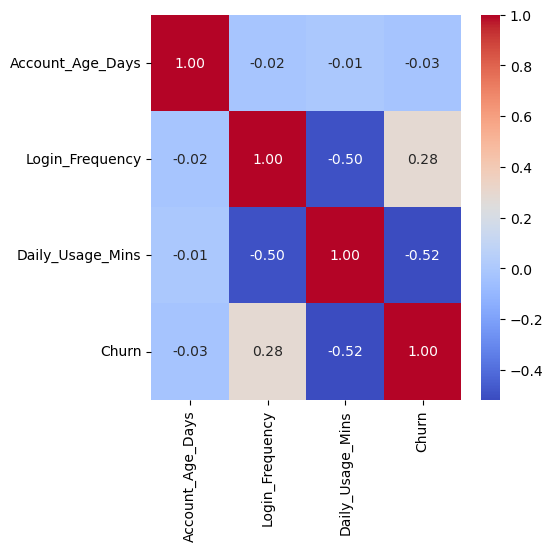

In [90]:
num_cols= dataset_duplicate.select_dtypes(include="number")
corr_matrix  =num_cols.corr()
plt.figure(figsize=(5,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

From the above data we can say that churn is highly dependent on login frequency.

In [29]:
corr_matrix  =num_cols.corr()
corr_matrix

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn
Account_Age_Days,1.000000,-0.019696,-0.005073,-0.031040
Login_Frequency,-0.019696,1.000000,-0.497883,0.284282
Daily_Usage_Mins,-0.005073,-0.497883,1.000000,-0.517569
Churn,-0.031040,0.284282,-0.517569,1.000000


number of retained users:  1263
mean usage time:  47.68250197941409


Text(0.5, 1.0, 'sepration between active and non active users')

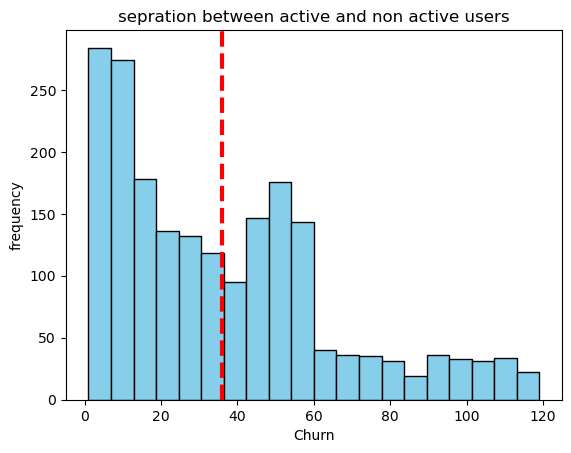

In [61]:
active=dataset_duplicate.query("Churn == 0").count()
active_dataset=dataset_duplicate.query("Churn == 0")
mean_usage_time=active_dataset["Daily_Usage_Mins"].mean()
print("number of retained users: ",active.Churn)
print("mean usage time: ",mean_usage_time)


plt.hist(dataset_duplicate["Daily_Usage_Mins"],bins=20,color='skyblue',edgecolor='black')
plt.axvline(
    x=36,
    label="Mean Usage Time",
    color="red",
    linewidth=3,
    linestyle="--"
)
plt.xlabel("Churn")
plt.ylabel("frequency")
plt.title("sepration between active and non active users")


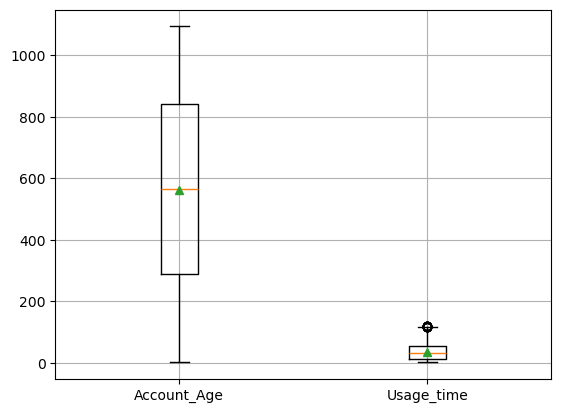

In [68]:
plt.boxplot([dataset_duplicate["Account_Age_Days"],dataset_duplicate["Daily_Usage_Mins"]],tick_labels=["Account_Age","Usage_time"],showmeans=True)
plt.grid(True)

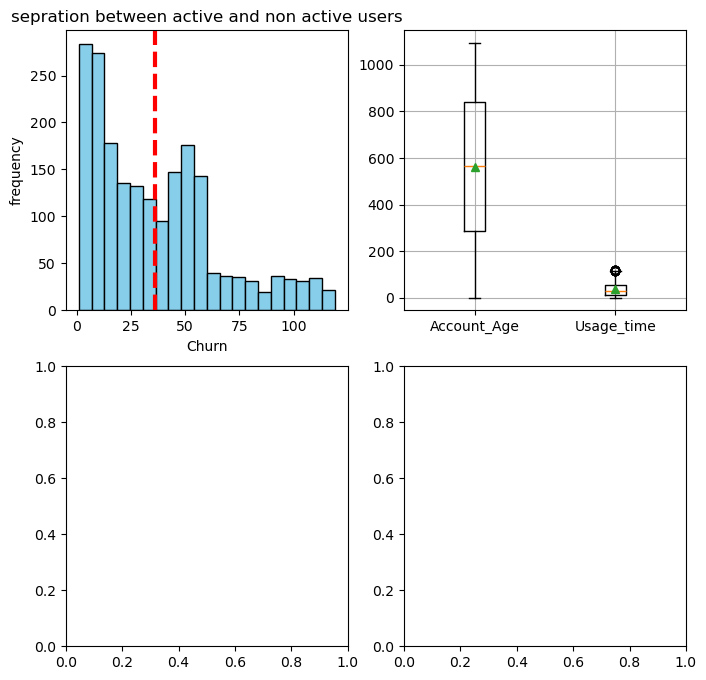

In [93]:
fig , ax =plt.subplots(2,2, figsize=(8,8))

ax[0][0].hist(dataset_duplicate["Daily_Usage_Mins"],bins=20,color='skyblue',edgecolor='black')
ax[0][0].axvline(
    x=36,
    label="Mean Usage Time",
    color="red",
    linewidth=3,
    linestyle="--"
)
ax[0][0].set_xlabel("Churn")
ax[0][0].set_ylabel("frequency")
ax[0][0].set_title("sepration between active and non active users")
fig.tight_layout

ax[0][1].boxplot([dataset_duplicate["Account_Age_Days"],dataset_duplicate["Daily_Usage_Mins"]],tick_labels=["Account_Age","Usage_time"],showmeans=True)
ax[0][1].grid(True)



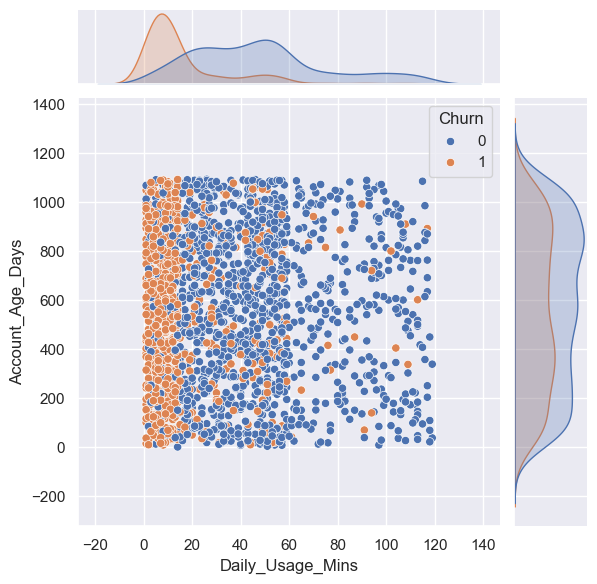

In [123]:
sns.set_theme(style="darkgrid")
sns.jointplot(
    data= dataset_duplicate, 
    x="Daily_Usage_Mins",
    y="Account_Age_Days",
    hue="Churn",
    #style="Churn"
)

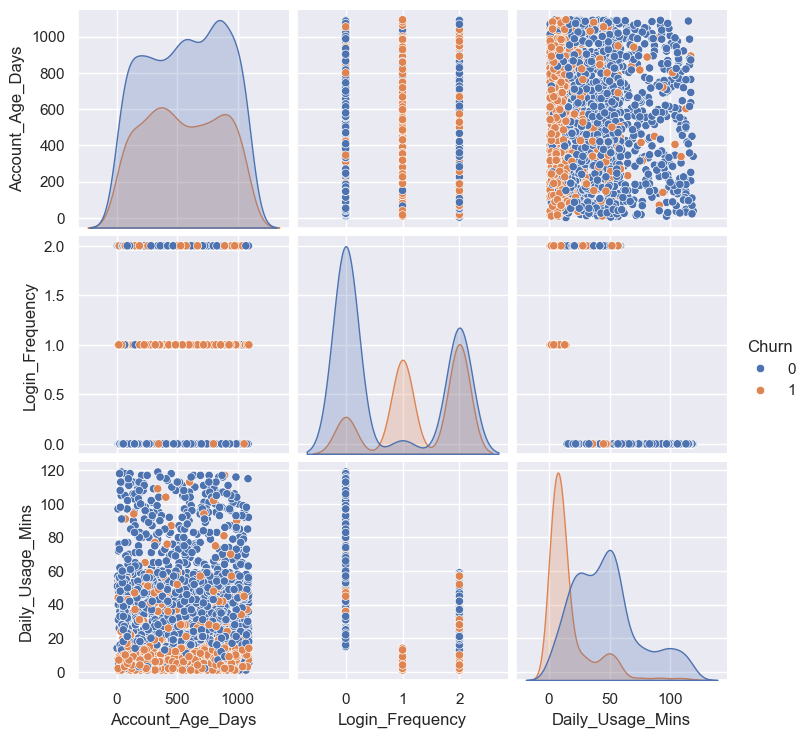

In [137]:
sns.pairplot(data=dataset_duplicate,hue="Churn")

<Axes: xlabel='Account_Age_Days', ylabel='Count'>

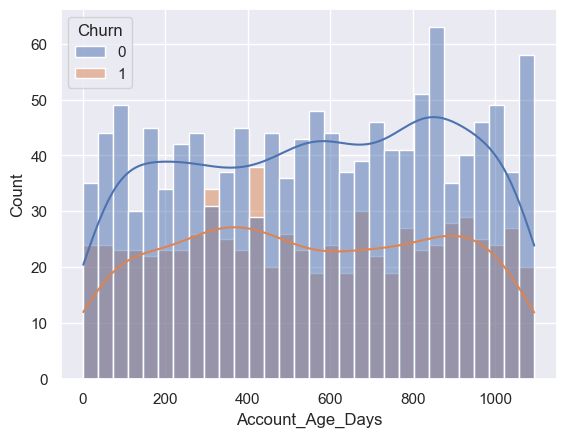

In [120]:
fig , ax= plt.subplots()

sns.histplot(
    data=dataset_duplicate,
    x="Account_Age_Days",
    bins=30,
    kde=True,
    hue="Churn",
    color
    ax=ax
)

<Axes: xlabel='Daily_Usage_Mins', ylabel='Count'>

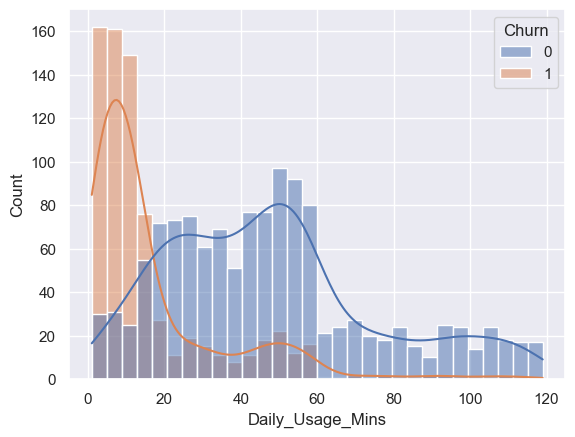

In [167]:
fig , ax= plt.subplots()

sns.histplot(
    data=dataset_duplicate,
    x="Daily_Usage_Mins",
    bins=30,
    hue="Churn",
    ax=ax,
    kde=True)

In [31]:
X_test.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins
0,269,Daily,43
1,439,Rarely,9
2,18,Rarely,1
3,405,Daily,22
4,24,Daily,88


In [35]:
X_test['Login_Frequency'] = X_test['Login_Frequency'].astype(str)
X_test['Login_Frequency'] = enc.transform(X_test[['Login_Frequency']])

In [36]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X,y)
y_pred=lr.predict(X_test)


        
        
    

In [34]:
print(X_test.dtypes)

Account_Age_Days     int64
Login_Frequency     object
Daily_Usage_Mins     int64
dtype: object


In [45]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score ,f1_score

print("Precision:", precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))


Precision: 0.6666666666666666
Recall: 0.6549707602339181
f1: 0.6607669616519174
accuracy: 0.77
confusion_matrix:
 [[273  56]
 [ 59 112]]


In [48]:
from sklearn.naive_bayes import GaussianNB

nb_model =GaussianNB()
nb_model.fit(X,y)
y_pred = nb_model.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))

Precision: 0.6020408163265306
Recall: 0.6900584795321637
f1: 0.6430517711171662
accuracy: 0.738
confusion_matrix:
 [[251  78]
 [ 53 118]]


In [51]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X,y)
y_pred = knn.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))

Precision: 0.695364238410596
Recall: 0.6140350877192983
f1: 0.6521739130434783
accuracy: 0.776
confusion_matrix:
 [[283  46]
 [ 66 105]]


In [52]:
from sklearn.tree import DecisionTreeClassifier

dc = DecisionTreeClassifier(max_depth=4)
dc.fit(X,y)

y_pred = dc.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))

Precision: 0.8059701492537313
Recall: 0.631578947368421
f1: 0.7081967213114754
accuracy: 0.822
confusion_matrix:
 [[303  26]
 [ 63 108]]


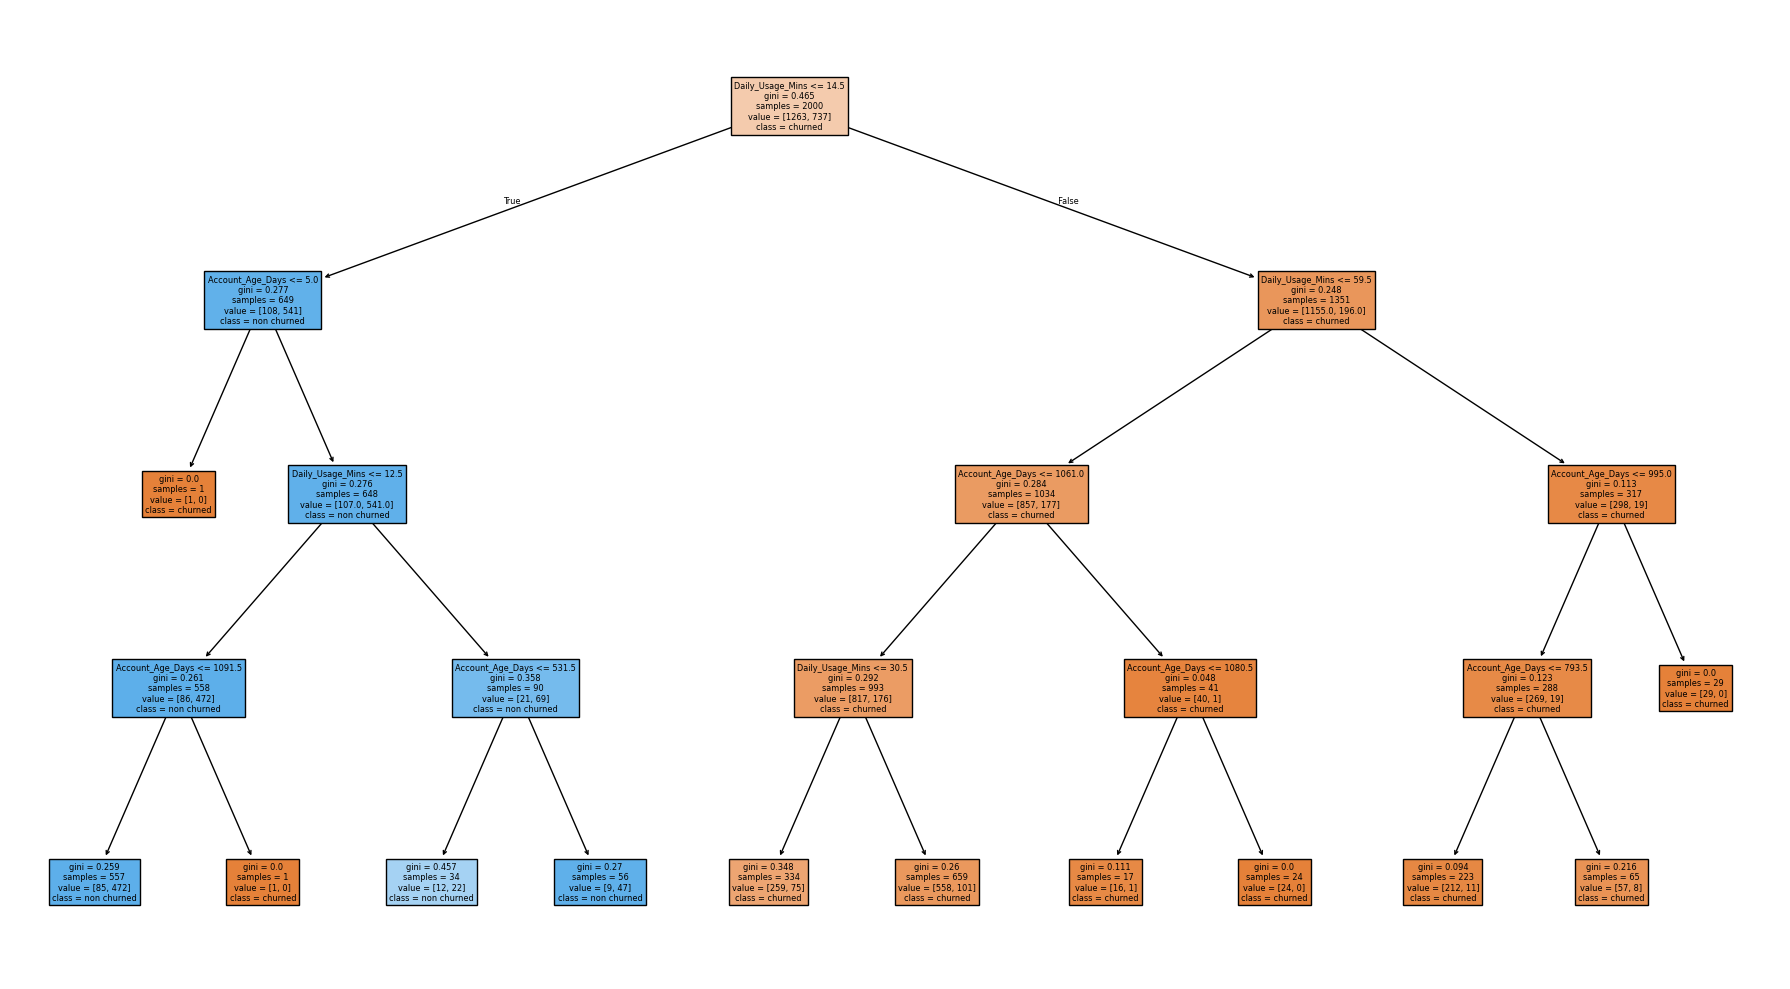

In [54]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
plot_tree(
    dc,
    feature_names=X.columns,
    class_names=["churned", "non churned"],
    filled=True
)

plt.tight_layout()

In [154]:
y_pred=dc.predict(X_test)
y_pred_train=dc.predict(X)
#checking overfitting
print("accuracy" ,accuracy_score(y_pred,y_test))
print("training_accuracy" ,accuracy_score(y,y_pred_train))

print("Precision:", precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))


accuracy 0.822
training_accuracy 0.849
Precision: 0.8059701492537313
Recall: 0.631578947368421
f1: 0.7081967213114754
accuracy: 0.822
confusion_matrix:
 [[303  26]
 [ 63 108]]


In [153]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier( n_estimators=501,max_depth=4,oob_score=True,random_state =42 )
rf.fit(X,y)

y_pred=rf.predict(X_test)
print("accuracy" ,accuracy_score(y_pred,y_test)*100)
print("OOB_SCORE" ,rf.oob_score_*100,"%")
print("Precision:", precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))


accuracy 82.39999999999999
OOB_SCORE 84.8 %
Precision: 0.8074074074074075
Recall: 0.6374269005847953
f1: 0.7124183006535948
accuracy: 0.824
confusion_matrix:
 [[303  26]
 [ 62 109]]


In [168]:
y_pred

array([0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,

In [151]:
from sklearn.svm import SVC
svm_model=SVC()
svm_model.fit(X,y)

y_pred = svm_model.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))


Precision: 0.6477987421383647
Recall: 0.6023391812865497
f1: 0.6242424242424243
accuracy: 0.752
confusion_matrix:
 [[273  56]
 [ 68 103]]


In [152]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier(n_estimators=201,learning_rate=0.1)
gbc.fit(X,y)

y_pred = gbc.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))



Precision: 0.7753623188405797
Recall: 0.6257309941520468
f1: 0.6925566343042071
accuracy: 0.81
confusion_matrix:
 [[298  31]
 [ 64 107]]
